<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Revisión Sistemática PRISMA</b>
            </font></p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Screening Fase 1: Título y Abstract (Votación por Mayoría)
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                Francisco Flores | Febrero 2026
            </font></p>
        </td>  
    </tr>
</table>

Este notebook automatiza el **screening PRISMA Fase 1** utilizando un sistema de votación por mayoría con 4 evaluaciones independientes por artículo.

**Metodología:**
- Cada artículo es evaluado 4 veces con prompts diferentes
- Cada evaluación responde 3 preguntas de screening
- La decisión final se determina por votación por mayoría

**Criterios de evaluación:**
- Q1: ¿El paper trata sobre fine-tuning de Large Language Models?
- Q2: ¿El paper evalúa Full Fine-Tuning, LoRA, Adapters, Prefix Tuning, RLHF o DPO?
- Q3: ¿El paper reporta evaluación empírica con métricas cuantitativas?

**Decisión por votación:**
- **Accepted:** 3 o 4 evaluaciones dicen INCLUIR
- **Rejected:** 3 o 4 evaluaciones dicen EXCLUIR
- **Undecided:** Empate 2-2 o resultados mixtos

---

## <font color='264CC7'>Configuración Inicial</font>

Importación de librerías necesarias para el procesamiento de datos, comunicación con la API de OpenAI, y generación de visualizaciones.

In [1]:
# - Importar librerías necesarias y configurar API de OpenAI -

# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librería para interactuar con API de OpenAI
from openai import OpenAI

# Librerías auxiliares
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
from pydantic import BaseModel
import warnings
warnings.filterwarnings('ignore')

# Cargar variables de entorno desde archivo .env
import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError("No se encontró OPENAI_API_KEY en el archivo .env")

# Crear cliente OpenAI
client = OpenAI(api_key=api_key)

print("Configuración completada")

Configuración completada


## <font color='264CC7'>Definición de Estructura de Respuesta</font>

Modelo Pydantic para respuestas estructuradas de la API. Define el esquema de datos esperado en cada evaluación.

In [2]:
# - Definir esquema de respuesta estructurada -

class EvaluacionArticulo(BaseModel):
    """
    Esquema de respuesta para evaluación de artículos.
    Cada campo representa una decisión binaria.
    """
    incluir: bool  # True si el artículo cumple los 3 criterios, False en caso contrario

## <font color='264CC7'>Prompts del Sistema</font>

Definición de los 4 prompts diferentes que evaluarán cada artículo. Cada prompt formula las mismas 3 preguntas con diferente redacción para obtener evaluaciones independientes.

In [3]:
# - Definir los 4 system messages para votación por mayoría -

system_messages = [
    # Prompt 1: Evaluador experto en revisiones sistemáticas
    (
        "You are an expert evaluator for systematic literature reviews on fine-tuning techniques for Large Language Models.\n\n"
        "Evaluate if an article is relevant for a review on fine-tuning techniques (Full Fine-Tuning, LoRA, Adapters, Prefix Tuning, RLHF, DPO) for LLMs.\n\n"
        "The article must meet ALL 3 criteria:\n"
        "1. Discusses fine-tuning of Large Language Models (GPT, LLaMA, Mistral, Claude, Falcon, BLOOM, OPT) - NOT smaller models like BERT/RoBERTa\n"
        "2. Evaluates at least ONE technique: Full Fine-Tuning, LoRA, Adapters, Prefix Tuning, RLHF, or DPO\n"
        "3. Reports empirical evaluation with quantitative metrics (accuracy, F1, BLEU, ROUGE, perplexity, benchmark scores)\n\n"
        "Respond with True if ALL criteria are met, False otherwise."
    ),
    
    # Prompt 2: Revisor académico especializado
    (
        "As a senior academic reviewer specializing in NLP and large-scale language models, "
        "assess whether this article contributes to the literature on fine-tuning methods for LLMs.\n\n"
        "The article is relevant ONLY if it:\n"
        "1. Focuses on Large Language Models (models explicitly identified as LLMs such as GPT-family, LLaMA-family, Mistral, Claude, Falcon, BLOOM, OPT, or similar)\n"
        "2. Presents or evaluates fine-tuning approaches including Full Fine-Tuning, LoRA, Adapters, Prefix Tuning, RLHF, or DPO\n"
        "3. Includes quantitative experimental results with performance metrics\n\n"
        "Return True if the article meets all requirements, False if any requirement is missing."
    ),
    
    # Prompt 3: Investigador en ML evaluando relevancia
    (
        "You are a machine learning researcher evaluating papers for a systematic review on parameter-efficient and alignment methods for Large Language Models.\n\n"
        "Determine if this article should be included based on:\n"
        "1. Subject matter: Fine-tuning of Large Language Models (explicitly mentions LLMs like GPT, LLaMA, Mistral, Claude, Falcon, BLOOM, OPT - excludes BERT-scale models)\n"
        "2. Methods covered: At least one of Full Fine-Tuning, LoRA, Adapters, Prefix Tuning, RLHF, or DPO is evaluated\n"
        "3. Empirical validation: Reports quantitative metrics such as accuracy, F1, BLEU, ROUGE, perplexity, or benchmark scores (MMLU, HellaSwag, etc.)\n\n"
        "Respond True if all three conditions hold, False otherwise."
    ),
    
    # Prompt 4: Experto en evaluación metodológica
    (
        "As an expert in systematic literature reviews with focus on reproducible research in NLP, "
        "evaluate if this article meets inclusion criteria for a study on LLM fine-tuning techniques.\n\n"
        "Inclusion criteria (ALL must be satisfied):\n"
        "1. The paper discusses fine-tuning approaches specifically for Large Language Models (models identified as LLMs such as GPT, LLaMA, Mistral, Claude, Falcon, BLOOM, OPT) - NOT encoder-only models like BERT or RoBERTa\n"
        "2. The paper evaluates one or more of these techniques: Full Fine-Tuning, LoRA, Adapters, Prefix Tuning, RLHF, DPO\n"
        "3. The paper presents empirical results with quantitative performance metrics (accuracy, F1 score, BLEU, ROUGE, perplexity, or standardized benchmark scores)\n\n"
        "Return True only if ALL criteria are met, False if any criterion fails."
    )
]

print(f"Sistema configurado con {len(system_messages)} evaluadores independientes")

Sistema configurado con 4 evaluadores independientes


## <font color='264CC7'>Función de Evaluación</font>

Función que realiza la evaluación de un artículo usando la API de OpenAI con respuestas estructuradas mediante Pydantic.

In [4]:
# - Función para evaluar artículo con un prompt específico -

def evaluate_article(title, abstract, keywords, system_message, model="gpt-4o-mini"):
    """
    Evalúa un artículo usando la API de OpenAI con structured outputs.
    
    Args:
        title: Título del artículo
        abstract: Resumen del artículo
        keywords: Palabras clave
        system_message: Prompt del sistema
        model: Modelo de OpenAI a utilizar
        
    Returns:
        bool: True si el artículo cumple criterios, False en caso contrario
    """
    prompt = (
        f"Title: {title}\n\n"
        f"Abstract: {abstract}\n\n"
        f"Keywords: {keywords}\n\n"
        "Based on the provided information, does this article meet ALL the inclusion criteria? "
        "Respond with True if ALL criteria are met, False otherwise."
    )
    
    try:
        response = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": prompt}
            ],
            response_format=EvaluacionArticulo,
            temperature=0.0
        )
        return response.choices[0].message.parsed.incluir
    except Exception as e:
        print(f"Error en evaluación: {str(e)}")
        return None

## <font color='264CC7'>Función de Votación</font>

Implementación del sistema de votación por mayoría que combina las 4 evaluaciones independientes en una decisión final.

In [5]:
# - Función para determinar veredicto final por mayoría -

def majority_vote(votes):
    """
    Determina veredicto final basado en votación por mayoría.
    
    Args:
        votes: Lista de 4 booleanos (True/False) de las evaluaciones
        
    Returns:
        str: 'Accepted', 'Rejected', o 'Undecided'
    """
    # Contar votos válidos
    valid_votes = [v for v in votes if v is not None]
    
    if len(valid_votes) == 0:
        return 'Undecided'
    
    true_count = valid_votes.count(True)
    false_count = valid_votes.count(False)
    
    # Mayoría para Accepted
    if true_count > false_count:
        return 'Accepted'
    # Mayoría para Rejected
    elif false_count > true_count:
        return 'Rejected'
    # Empate
    else:
        return 'Undecided'

print("Sistema de votación configurado")

Sistema de votación configurado


## <font color='264CC7'>Carga y Preparación de Datos</font>

Carga del archivo Excel exportado desde Scopus/Parsifal, validación de columnas requeridas, y preparación de datos para el screening.

In [6]:
# - Cargar y validar dataset de artículos -

# Cargar archivo Excel
df = pd.read_excel("Data/articles.xls")

# Eliminar duplicados si existen
if 'status' in df.columns:
    duplicados = (df['status'] == 'Duplicated').sum()
    if duplicados > 0:
        print(f"Duplicados encontrados y eliminados: {duplicados}")
        df = df[df['status'] != 'Duplicated']

# Validar columnas requeridas
required_cols = ['title', 'abstract']
if not all(col in df.columns for col in required_cols):
    raise ValueError(f"El archivo debe contener las columnas: {required_cols}")

# Usar author_keywords si keywords no existe
if 'keywords' not in df.columns and 'author_keywords' in df.columns:
    df['keywords'] = df['author_keywords']
elif 'keywords' not in df.columns:
    df['keywords'] = ""

# Rellenar valores NaN
df['title'] = df['title'].fillna("No title")
df['abstract'] = df['abstract'].fillna("No abstract")
df['keywords'] = df['keywords'].fillna("")

print(f"Total de artículos cargados: {len(df)}")
print(f"Columnas disponibles: {list(df.columns)}")
print("\nPrimeras 3 filas:")
df[['title', 'abstract']].head(3)

Total de artículos cargados: 139
Columnas disponibles: ['bibtex_key', 'title', 'author', 'journal', 'year', 'source', 'pages', 'volume', 'abstract', 'document_type', 'doi', 'url', 'affiliation', 'author_keywords', 'keywords', 'publisher', 'issn', 'language', 'note', 'selection_criteria', 'created_at', 'updated_at', 'created_by', 'updated_by', 'status', 'comments']

Primeras 3 filas:


,title,abstract
0,ENHANCING ASPECT-BASED FINANCIAL SENTIMENT ANA...,The subject of research in the article explore...
1,Vision-Language Model for Generating Textual D...,Background: The automatic generation of radiol...
2,SumLLaMA: Efficient Contrastive Representation...,"In software maintenance, concise summaries of ..."


### <font color='264CC7'>Configuración de Ejecución</font>

Selección del modo de procesamiento. En **modo TEST**, se procesan únicamente los primeros 5 artículos para validar el funcionamiento del sistema antes de ejecutar el screening completo. Para procesar el dataset completo, cambiar `SAMPLE_SIZE = None` en la siguiente celda.

In [7]:
# - Configurar modo de ejecución -

SAMPLE_SIZE = None  # TEST: 5 artículos | None: todos los artículos

if SAMPLE_SIZE:
    df_screen = df.head(SAMPLE_SIZE).copy()
    print(f"Modo TEST: procesando {SAMPLE_SIZE} artículos")
else:
    df_screen = df.copy()
    print(f"Modo PRODUCCION: procesando {len(df_screen)} artículos")

# Inicializar columnas de resultados
df_screen['vote_1'] = None
df_screen['vote_2'] = None
df_screen['vote_3'] = None
df_screen['vote_4'] = None
df_screen['veredicto_final'] = ""

print(f"\nArticulos a procesar: {len(df_screen)}")
print(f"Evaluaciones totales: {len(df_screen) * 4}")

Modo PRODUCCION: procesando 139 artículos

Articulos a procesar: 139
Evaluaciones totales: 556


## <font color='264CC7'>Ejecución del Screening</font>

Procesamiento secuencial de cada artículo mediante 4 evaluaciones independientes con la API de OpenAI. Cada artículo recibe 4 votos que luego se combinan mediante votación por mayoría.

In [8]:
# - Procesar artículos con sistema de votación -

start_time = time.time()
total_evaluations = len(df_screen) * 4
evaluations_done = 0

print("Iniciando evaluación con 4 votaciones por artículo...\n")

for idx, row in df_screen.iterrows():
    # Evaluar con los 4 prompts
    votes = []
    for i, system_message in enumerate(system_messages, 1):
        vote = evaluate_article(
            title=row['title'],
            abstract=row['abstract'],
            keywords=row['keywords'],
            system_message=system_message
        )
        votes.append(vote)
        
        # Guardar voto individual
        df_screen.at[idx, f'vote_{i}'] = vote
        
        evaluations_done += 1
        
        # Mostrar progreso cada 5 evaluaciones
        if evaluations_done % 5 == 0:
            elapsed = time.time() - start_time
            rate = evaluations_done / elapsed
            remaining = (total_evaluations - evaluations_done) / rate
            print(f"Progreso: {evaluations_done}/{total_evaluations} evaluaciones | "
                  f"{rate:.1f} eval/sec | ETA: {remaining/60:.1f} min")
    
    # Determinar veredicto final por mayoría
    veredicto = majority_vote(votes)
    df_screen.at[idx, 'veredicto_final'] = veredicto

elapsed_total = time.time() - start_time
print(f"Procesamiento completado en {elapsed_total/60:.2f} minutos")
print(f"Velocidad promedio: {total_evaluations/elapsed_total:.2f} evaluaciones/segundo")

Iniciando evaluación con 4 votaciones por artículo...

Progreso: 5/556 evaluaciones | 1.3 eval/sec | ETA: 7.2 min
Progreso: 10/556 evaluaciones | 1.4 eval/sec | ETA: 6.4 min
Progreso: 15/556 evaluaciones | 1.2 eval/sec | ETA: 7.3 min
Progreso: 20/556 evaluaciones | 1.3 eval/sec | ETA: 6.9 min
Progreso: 25/556 evaluaciones | 1.3 eval/sec | ETA: 7.0 min
Progreso: 30/556 evaluaciones | 1.3 eval/sec | ETA: 7.0 min
Progreso: 35/556 evaluaciones | 1.3 eval/sec | ETA: 6.8 min
Progreso: 40/556 evaluaciones | 1.3 eval/sec | ETA: 6.5 min
Progreso: 45/556 evaluaciones | 1.3 eval/sec | ETA: 6.5 min
Progreso: 50/556 evaluaciones | 1.3 eval/sec | ETA: 6.3 min
Progreso: 55/556 evaluaciones | 1.4 eval/sec | ETA: 6.2 min
Progreso: 60/556 evaluaciones | 1.4 eval/sec | ETA: 6.0 min
Progreso: 65/556 evaluaciones | 1.4 eval/sec | ETA: 5.9 min
Progreso: 70/556 evaluaciones | 1.4 eval/sec | ETA: 5.8 min
Progreso: 75/556 evaluaciones | 1.4 eval/sec | ETA: 5.6 min
Progreso: 80/556 evaluaciones | 1.4 eval/sec |

## <font color='264CC7'>Análisis de Resultados</font>

Generación de estadísticas descriptivas y visualizaciones para evaluar los resultados del screening. Se incluyen tablas de frecuencia, gráficos de distribución, y análisis de consenso entre evaluadores.

### <font color='264CC7'>Estadísticas Generales</font>

In [9]:
# - Resumen estadístico de decisiones -

print("RESULTADOS DEL SCREENING FASE 1 - VOTACION POR MAYORIA\n")

print(f"Total de artículos procesados: {len(df_screen)}")
print(f"Total de evaluaciones realizadas: {len(df_screen) * 4}\n")

print("Distribución de veredictos finales:")
print(df_screen['veredicto_final'].value_counts())

accepted_count = (df_screen['veredicto_final'] == 'Accepted').sum()
rejected_count = (df_screen['veredicto_final'] == 'Rejected').sum()
undecided_count = (df_screen['veredicto_final'] == 'Undecided').sum()

print(f"\nTasas:")
print(f"  Accepted:  {accepted_count} ({accepted_count/len(df_screen)*100:.1f}%)")
print(f"  Rejected:  {rejected_count} ({rejected_count/len(df_screen)*100:.1f}%)")
print(f"  Undecided: {undecided_count} ({undecided_count/len(df_screen)*100:.1f}%)")

print(f"\nArticulos que pasan a Fase 2 (Accepted): {accepted_count}")
print(f"Articulos para revision manual (Undecided): {undecided_count}")

RESULTADOS DEL SCREENING FASE 1 - VOTACION POR MAYORIA

Total de artículos procesados: 139
Total de evaluaciones realizadas: 556

Distribución de veredictos finales:
veredicto_final
Accepted     104
Rejected      27
Undecided      8
Name: count, dtype: int64

Tasas:
  Accepted:  104 (74.8%)
  Rejected:  27 (19.4%)
  Undecided: 8 (5.8%)

Articulos que pasan a Fase 2 (Accepted): 104
Articulos para revision manual (Undecided): 8


### <font color='264CC7'>Análisis de Consenso entre Evaluadores</font>

In [10]:
# - Analizar nivel de acuerdo entre evaluadores -

# Contar consensos
consenso_unanime = 0  # 4-0 o 0-4
consenso_fuerte = 0   # 3-1 o 1-3
empate = 0            # 2-2

for idx, row in df_screen.iterrows():
    votes = [row['vote_1'], row['vote_2'], row['vote_3'], row['vote_4']]
    valid_votes = [v for v in votes if v is not None]
    
    if len(valid_votes) == 4:
        true_count = valid_votes.count(True)
        
        if true_count == 4 or true_count == 0:
            consenso_unanime += 1
        elif true_count == 3 or true_count == 1:
            consenso_fuerte += 1
        else:
            empate += 1

print("Nivel de consenso entre evaluadores:\n")
print(f"  Consenso unánime (4-0): {consenso_unanime} ({consenso_unanime/len(df_screen)*100:.1f}%)")
print(f"  Consenso fuerte (3-1):  {consenso_fuerte} ({consenso_fuerte/len(df_screen)*100:.1f}%)")
print(f"  Empate (2-2):           {empate} ({empate/len(df_screen)*100:.1f}%)")

Nivel de consenso entre evaluadores:

  Consenso unánime (4-0): 100 (71.9%)
  Consenso fuerte (3-1):  31 (22.3%)
  Empate (2-2):           8 (5.8%)


### <font color='264CC7'>Visualizaciones</font>

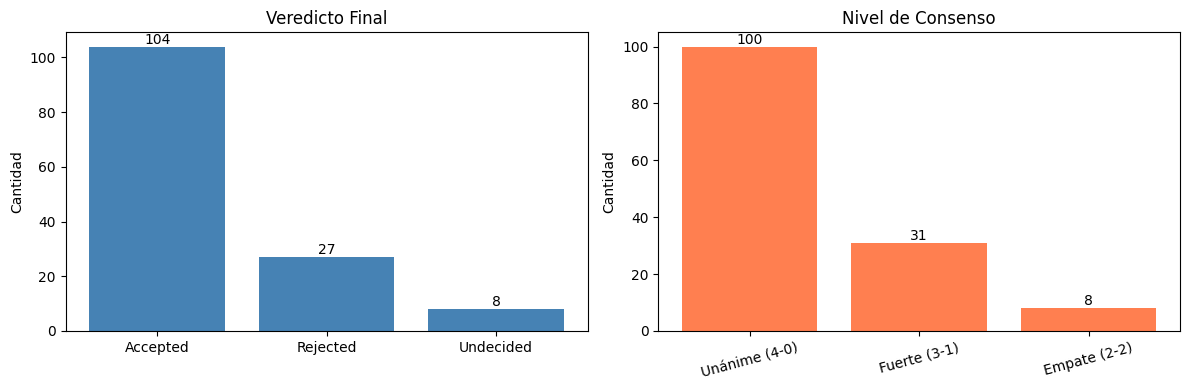

In [11]:
# - Generar gráficos de distribución -

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Veredicto final
veredicto_counts = df_screen['veredicto_final'].value_counts().reindex(
    ['Accepted', 'Rejected', 'Undecided'], fill_value=0
)
bars1 = axes[0].bar(veredicto_counts.index, veredicto_counts.values, color='steelblue')
axes[0].set_title('Veredicto Final')
axes[0].set_ylabel('Cantidad')
axes[0].set_xlabel('')

# Añadir valores en las barras
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')

# Gráfico 2: Consenso
consenso_data = pd.Series({
    'Unánime (4-0)': consenso_unanime,
    'Fuerte (3-1)': consenso_fuerte,
    'Empate (2-2)': empate
})
bars2 = axes[1].bar(consenso_data.index, consenso_data.values, color='coral')
axes[1].set_title('Nivel de Consenso')
axes[1].set_ylabel('Cantidad')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# Añadir valores en las barras
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## <font color='264CC7'>Exportación de Resultados</font>

Generación de archivo CSV con los resultados del screening para revisión manual y posterior procesamiento.

In [14]:
# - Exportar resultados del screening -

# Crear carpeta de exportación si no existe
output_dir = Path("Exports/Phase1")
output_dir.mkdir(parents=True, exist_ok=True)

# Renombrar columnas de votos según el rol de cada evaluador
df_screen_renamed = df_screen.copy()
df_screen_renamed = df_screen_renamed.rename(columns={
    'vote_1': 'evaluador_sistematico',      # Expert evaluator for systematic reviews
    'vote_2': 'revisor_academico',          # Senior academic reviewer
    'vote_3': 'investigador_ml',            # ML researcher
    'vote_4': 'experto_metodologico'        # Expert in systematic reviews methodology
})

# Preparar DataFrame para exportar
df_export = df_screen_renamed[[
    'title', 
    'evaluador_sistematico', 
    'revisor_academico', 
    'investigador_ml', 
    'experto_metodologico', 
    'veredicto_final'
]].copy()

# Exportar CSV
output_file = output_dir / "phase1_screening_results.csv"
df_export.to_csv(output_file, index=False)

print(f"Resultados exportados a: {output_file}")
print(f"Total de registros: {len(df_export)}")
print(f"\nDistribución de veredictos:")
print(df_export['veredicto_final'].value_counts())
print(f"\nPróximo paso: Revisar artículos 'Undecided' manualmente antes de proceder a Fase 2.")

Resultados exportados a: Exports\Phase1\phase1_screening_results.csv
Total de registros: 139

Distribución de veredictos:
veredicto_final
Accepted     104
Rejected      27
Undecided      8
Name: count, dtype: int64

Próximo paso: Revisar artículos 'Undecided' manualmente antes de proceder a Fase 2.
